[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/trim-filter-messages.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239435-lesson-4-trim-and-filter-messages)

# Filtering and trimming messages

## Review

Now, we have a deeper understanding of a few things: 

* How to customize the graph state schema
* How to define custom state reducers
* How to use multiple graph state schemas

## Goals

Now, we can start using these concepts with models in LangGraph!
 
In the next few sessions, we'll build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_openai

In [1]:
import os
from dotenv import load_dotenv

# Expand the tilde (~) to the full /home/user path
env_path = os.path.expanduser("~/.langchain.env")

# Load the file using the absolute path
load_dotenv(dotenv_path=env_path)

# Now you can access it like a normal environment variable
openai_api_key = os.getenv("OPENAI_API_KEY")
print(f"Current Working Directory: {os.getcwd()}")
print(f"Files in directory: {os.listdir('.')}")
if not openai_api_key:
    raise ValueError("OPENAI_API_KEY not found. Check your .env file!")

print("API Key loaded successfully.")

Current Working Directory: /home/mario-useche/workspace/repos/others/langchain-academy/module-2
Files in directory: ['state_db', 'trim-filter-messages.ipynb', 'state-schema.ipynb', 'state-reducers.ipynb', 'multiple-schemas.ipynb', 'studio', 'chatbot-external-memory.ipynb', 'chatbot-summarization.ipynb']
API Key loaded successfully.


We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for [tracing](https://docs.langchain.com/langsmith/observability-concepts).

We'll log to a project, `langchain-academy`. 

## Messages as state

First, let's define some messages.

In [2]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


Recall we can pass them to a chat model.

In [4]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
answer=llm.invoke(messages)
answer.pretty_print()

================================== Ai Message ==================================

In addition to whales, there are several fascinating ocean mammals you might want to explore:

1. **Dolphins**: Highly intelligent and social creatures, dolphins are known for their playful behavior and complex communication systems. There are several species, including the well-known bottlenose dolphin.

2. **Porpoises**: Similar to dolphins, porpoises are smaller and have different facial features. They tend to have a more reserved nature compared to their dolphin relatives.

3. **Seals**: Known for their distinctive appearances and adaptability, seals are divided into true seals and eared seals, such as sea lions and fur seals.

4. **Sea Lions**: These eared seals are known for their loud barks and ability to "walk" on land using their large flippers.

5. **Walruses**: Easily recognized by their large tusks and whiskers, walruses are social animals commonly found in Arctic regions.

6. **Manatees**: Al

We can run our chat model in a simple graph with `MessagesState`.

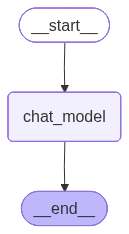

In [5]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

In addition to whales, there are several fascinating ocean mammals you can explore:

1. **Dolphins**: Known for their intelligence and playful behavior, dolphins are part of the cetacean family, which also includes whales and porpoises.

2. **Porpoises**: Similar to dolphins, but generally smaller and with different facial features and teeth, porpoises are also highly intelligent marine mammals.

3. **Seals**: Part of the pinniped family, seals are semi-aquatic and are known for their sleek bodies and flippers, which make them excellent swimmers.

4. **Sea Lions**: Often confused with seals, sea lions are more so

## Reducer

A practical challenge when working with messages is managing long-running conversations. 

Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

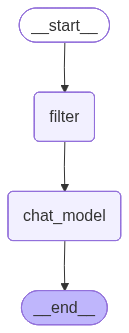

In [7]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There’s a rich diversity of ocean mammals you might find fascinating beyond whales! Here are a few notable ones:

1. **Dolphins**: These intelligent and highly social creatures belong to the family Delphinidae. Bottlenose dolphins are among the most familiar, but species such as the orca (killer whale) and the spinner dolphin are also captivating.

2. **Porpoises**: Similar to dolphins but generally smaller and stouter, porpoises belong to the family Phocoenidae. The harbor porpoise is a well-known example.

3. **Seals**: These semi-aquatic marine mammals, belonging to the family Phocidae, include species like th

## Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

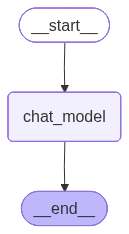

In [9]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take our existing list of messages, append the above LLM response, and append a follow-up question.

In [10]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

In [11]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There’s a rich diversity of ocean mammals you might find fascinating beyond whales! Here are a few notable ones:

1. **Dolphins**: These intelligent and highly social creatures belong to the family Delphinidae. Bottlenose dolphins are among the most familiar, but species such as the orca (killer whale) and the spinner dolphin are also captivating.

2. **Porpoises**: Similar to dolphins but generally smaller and stouter, po

In [12]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There’s a rich diversity of ocean mammals you might find fascinating beyond whales! Here are a few notable ones:

1. **Dolphins**: These intelligent and highly social creatures belong to the family Delphinidae. Bottlenose dolphins are among the most familiar, but species such as the orca (killer whale) and the spinner dolphin are also captivating.

2. **Porpoises**: Similar to dolphins but generally smaller and stouter, po

The state has all of the mesages.

But, let's look at the LangSmith trace to see that the model invocation only uses the last message:

https://smith.langchain.com/public/75aca3ce-ef19-4b92-94be-0178c7a660d9/r

## Trim messages

Another approach is to [trim messages](https://docs.langchain.com/oss/python/langgraph/add-memory#trim-messages), based upon a set number of tokens. 

This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the `trim_messages` below.

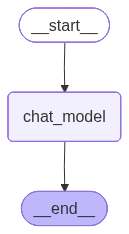

In [13]:
from langchain_core.messages import trim_messages

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=ChatOpenAI(model="gpt-4o"),
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [21]:
# Example of trimming messages
trimmed_messages = trim_messages(
    messages,
    max_tokens=200,
    strategy="last",
    token_counter=ChatOpenAI(model="gpt-4o"),
    allow_partial=True
)
for m in trimmed_messages:
    m.pretty_print()

================================== Ai Message ==================================

Currently, narwhals are considered "Near Threatened" by the International Union for Conservation of Nature (IUCN). Threats to their survival include climate change, which reduces sea ice habitats, and human activities such as shipping, oil, and gas exploration, which increase noise pollution in their environment. Additionally, they are occasionally hunted by indigenous peoples for their tusks and skin, although such hunting is typically regulated.

### Cultural Significance:
The narwhal tusk has historically been valued and treated with mystical significance, often mistaken for a unicorn horn in medieval Europe and believed to have magical properties. Indigenous cultures in the Arctic have legends and traditions surrounding narwhals and rely on them as an important resource.

Narwhals are a prime example of the unique adaptations and biodiversity present in Arctic ecosystems, and they continue to be a sub

In [22]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=ChatOpenAI(model="gpt-4o"),
            allow_partial=False
        )

[HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Lance', id='9405ac7d-fcd1-4fed-a4d5-a5bfbc3f993b')]

In [23]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

Let's look at the LangSmith trace to see the model invocation:

https://smith.langchain.com/public/b153f7e9-f1a5-4d60-8074-f0d7ab5b42ef/r